In [ ]:
#outliers


In [1]:
import pandas as pd

In [ ]:
#df=pd.read_csv("sal.csv")

In [2]:
import pandas as pd
df = pd.read_csv("sal.csv")
print(df)


            Salary
0     32483.570765
1     29308.678494
2     33238.442691
3     37615.149282
4     28829.233126
..             ...
97    31305.276361
98    30025.567283
99    28827.064333
100  100000.000000
101  120000.000000

[102 rows x 1 columns]


In [14]:
#pip install seaborn

In [15]:
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='Salary'>

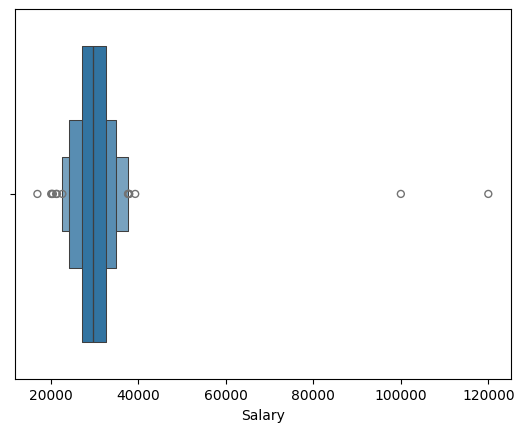

In [16]:
sns.boxenplot(df,x="Salary")

<Axes: xlabel='None', ylabel='Salary'>

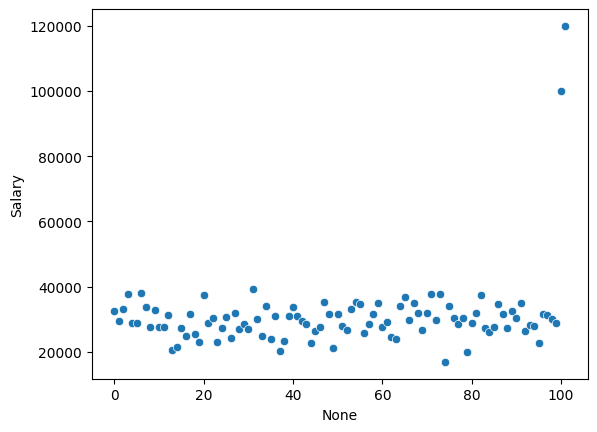

In [17]:
sns.scatterplot(x=df.index, y=df.Salary)

<Axes: xlabel='Salary', ylabel='Count'>

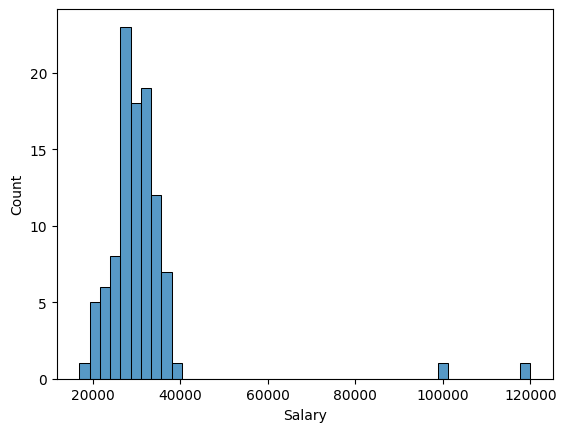

In [18]:
sns.histplot(df.Salary)

In [21]:
#pip install plotly

In [22]:
import plotly.express as px


In [23]:
px.box(df.Salary)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'variable=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa'},
              'name': '',
              'notched': False,
              'offsetgroup': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'box',
              'x': array(['Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary', 'Salary',
                          'Salary', 'Salary', 'Salary', 'Salary'], dtype=object),
              'x0': ' ',
              'xaxis': 'x',
              'y': {'bdata': ('eyhqh+S430DWs3JsK5/cQFRGhSrOOu' ... '4IHsQm3EAAAAAAAGr4QAAAAAAATP1A'),
                    'dtype': 'f8'},
              'y0': ' ',
              'yaxis': 'y'}],
    'layout': {'boxmode': 'group',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'variable'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'value'}}}
})

In [25]:
q1=df.Salary.quantile(0.25)
q3=df.Salary.quantile(0.75)

In [26]:
IQR=q3-q1

In [27]:
IQR

np.float64(5500.900064185862)

In [28]:
L=q1-1.5*IQR
U=q3+1.5*IQR

In [29]:
L

np.float64(18793.39540497447)

In [30]:
U

np.float64(40796.99566171792)

In [31]:
cl_df=df[(df.Salary<U)&(df.Salary>L)]

In [32]:
cl_df.shape

(99, 1)

In [33]:
cl_df

,Salary
0,32483.570765
1,29308.678494
2,33238.442691
3,37615.149282
4,28829.233126
...,...
95,22682.425259
96,31480.601385
97,31305.276361
98,30025.567283


In [34]:
df[df.Salary>U]

,Salary
100,100000.0
101,120000.0


In [35]:
df[df.Salary<L]

,Salary
74,16901.27448


In [36]:
#z score method

In [37]:
M=df.Salary.mean()

In [39]:
S=df.Salary.std()

In [40]:
M

np.float64(31059.575895126993)

In [41]:
S

np.float64(12167.864764142028)

In [42]:
def z_score(data):
    z=(data-M)/S
    return z

In [43]:
df["z_score"]=df.Salary.apply(z_score)

In [44]:
df

,Salary,z_score
0,32483.570765,0.117029
1,29308.678494,-0.143895
2,33238.442691,0.179067
3,37615.149282,0.538761
4,28829.233126,-0.183298
...,...,...
97,31305.276361,0.020193
98,30025.567283,-0.084979
99,28827.064333,-0.183476
100,100000.000000,5.665778


In [45]:
df[(df["z_score"]>-3)&(df["z_score"]<3)]

,Salary,z_score
0,32483.570765,0.117029
1,29308.678494,-0.143895
2,33238.442691,0.179067
3,37615.149282,0.538761
4,28829.233126,-0.183298
...,...,...
95,22682.425259,-0.688465
96,31480.601385,0.034601
97,31305.276361,0.020193
98,30025.567283,-0.084979


In [47]:
df[df["z_score"]>3]

,Salary,z_score
100,100000.0,5.665778
101,120000.0,7.309452


In [48]:
df[df["z_score"]<-3]

,Salary,z_score


In [54]:
df[(df["z_score"]>-1) & (df["z_score"]<1)]

,Salary,z_score
0,32483.570765,0.117029
1,29308.678494,-0.143895
2,33238.442691,0.179067
3,37615.149282,0.538761
4,28829.233126,-0.183298
...,...,...
95,22682.425259,-0.688465
96,31480.601385,0.034601
97,31305.276361,0.020193
98,30025.567283,-0.084979


In [56]:
df[df["z_score"]<-1]

,Salary,z_score
74,16901.27448,-1.163581


In [57]:
df[df["z_score"]>1]

,Salary,z_score
100,100000.0,5.665778
101,120000.0,7.309452
